In [65]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
SEED=42

# Načtení datasetu se stanicemi

In [5]:
df = pl.read_parquet(r'kod\data\extracted\stanice_stk_a_sme\parquet\Stanice STK a SME.parquet', schema=stanice_schema)
describe(df)

(1411, 26)


,Stanice_Cislo,Stanice_Adresa_Kraj,Stanice_Adresa_Okres,Stanice_Adresa_Orp,Stanice_Adresa_Obec,Stanice_Adresa_Ulice,Stanice_Adresa_Psc,Stanice_Kontakt_Telefon,Stanice_Kontakt_Email,Provozovatel_Ico,...,Stk_Pritomno,Stk_Osvedceni_Kategorie,Adr_Pritomno,Adr_Osvedceni_Kategorie,SmeZkusebni_Pritomno,SmeZkusebni_Osvedceni_Kategorie,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,110301,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Koněvova 411/143,13000,704372631,emitech@email.cz,17389631,...,False,NaN,False,NaN,False,NaN,True,4.0,2.0,2.0
1,110302,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Osiková 2688/2,13000,605339922,stk3130@seznam.cz,7100639,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0
2,110401,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Lipenská 616,14900,608238686,m.o.t.service@centrum.cz,71715177,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0
3,110501,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Bavorská 2666/16,15500,+420 271 077 890,ota.kolmann@daimlertruck.com,6418147,...,False,NaN,False,NaN,False,NaN,True,9.0,2.0,3.0
4,110502,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Jeremiášova 947/16,15500,774264790,autosprint.stodulky@gmail.com,11716541,...,False,NaN,False,NaN,False,NaN,True,7.0,2.0,3.0
5,110503,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Plzeňská 305/215e,15000,257216489,sen.k.trojan@seznam.cz,17145279,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0
6,110601,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Reinerova 811/5,16300,608910916,recepce@papousek.cz,48028321,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,2.0
7,110801,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Bešťákova 567/3,18200,722003300,stk@stkpraha8.cz,24847224,...,False,NaN,False,NaN,False,NaN,True,7.0,2.0,4.0
8,110802,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,K Ládví 925,18000,604288244,autoholub@email.cz,62421247,...,False,NaN,False,NaN,False,NaN,True,7.0,2.0,4.0
9,110901,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,"Kostelecká ul., parc.č.756/48,756/49,756/50,15788",19000,777277177,stk31.31@seznam.cz,7100639,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0


,0
Stanice_Cislo,1411 / 1411
Stanice_Adresa_Kraj,1411 / 1411
Stanice_Adresa_Okres,1411 / 1411
Stanice_Adresa_Orp,1411 / 1411
Stanice_Adresa_Obec,1411 / 1411
Stanice_Adresa_Ulice,1411 / 1411
Stanice_Adresa_Psc,1411 / 1411
Stanice_Kontakt_Telefon,1411 / 1411
Stanice_Kontakt_Email,1411 / 1411
Provozovatel_Ico,1411 / 1411


Stanice_Cislo,Stanice_Adresa_Kraj,Stanice_Adresa_Okres,Stanice_Adresa_Orp,Stanice_Adresa_Obec,Stanice_Adresa_Ulice,Stanice_Adresa_Psc,Stanice_Kontakt_Telefon,Stanice_Kontakt_Email,Provozovatel_Ico,Provozovatel_Nazev,Provozovatel_Adresa_Obec,Provozovatel_Adresa_Ulice,Provozovatel_Adresa_Psc,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Stk_Osvedceni_Kategorie,Adr_Pritomno,Adr_Osvedceni_Kategorie,SmeZkusebni_Pritomno,SmeZkusebni_Osvedceni_Kategorie,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],str,list[str],str,list[str],str,list[str],list[str],list[str]
"""110301""","""Hlavní město Praha""","""Hlavní město Praha""","""Hlavní město Praha""","""Praha""","""Koněvova 411/143""","""13000""","""704372631""","""emitech@email.cz""","""17389631""","""Emitech s.r.o.""","""Praha""","""Choceradská 3046""","""14100""","""704 372 000""","""emitech@email.cz""","""False""",null,"""False""",null,"""False""",null,"""True""","[""M1"", ""M2"", … ""N2""]","[""NERIZENY"", ""RIZENY""]","[""BA"", ""NM""]"


# Chybějící hodnoty

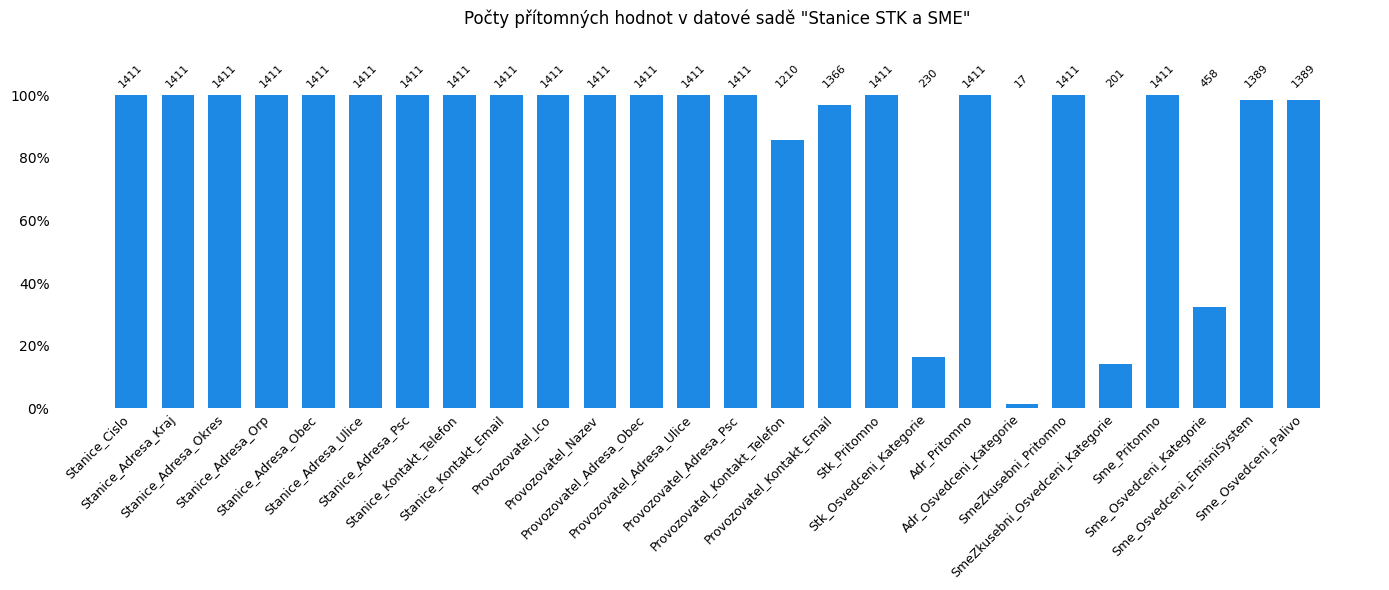

In [72]:
# Výpočet metrik
total_rows = len(df)
null_counts = df.null_count().row(0)
non_null_counts = [total_rows - count for count in null_counts]
ratios = [count / total_rows for count in non_null_counts]
columns = df.columns

# Inicializace grafu
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(columns, ratios, color='#1e88e5', width=0.7)

# Horní popisky s absolutními počty
for i, count in enumerate(non_null_counts):
    ax.text(i, 1.02, str(count), ha='center', va='bottom', rotation=45, fontsize=8)

# Formátování os a vzhledu
ax.set_title('Počty přítomných hodnot v datové sadě "Stanice STK a SME"')
ax.set_ylim(0, 1.2)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')

# Odstranění nadbytečných linií grafu
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Export do SVG
plt.tight_layout()
plt.savefig("kod/explorace/stanice_pritomne_hodnoty.svg", format="svg", bbox_inches='tight')
plt.show()

# Oprávnění

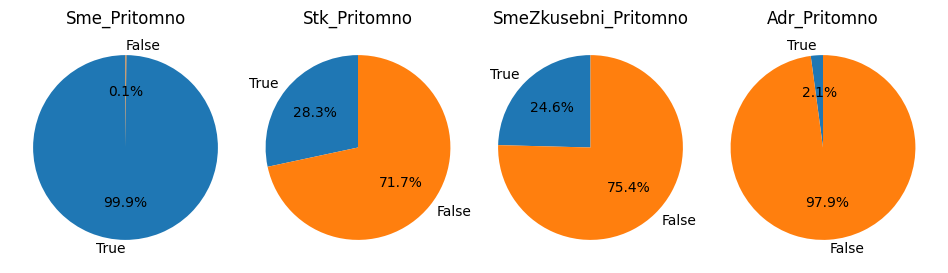

In [ ]:
cols = ["Sme_Pritomno","Stk_Pritomno","SmeZkusebni_Pritomno","Adr_Pritomno"]

fig, axes = plt.subplots(1, 4, figsize=(12,3))
for ax, col in zip(axes, cols):
    t = df.select((pl.col(col) == 'True').sum()).item()
    f = df.height - t
    ax.pie([t, f], labels=["True","False"], autopct="%1.1f%%", startangle=90)
    ax.set_title(col)
    ax.set_aspect("equal")

fig.subplots_adjust(wspace=0)  # nulové mezery mezi grafy
fig.savefig("kod/explorace/stanice_opravneni.svg", format="svg", bbox_inches='tight')  # minimalizuje okraje
plt.show()

# Počty stanic v krajích

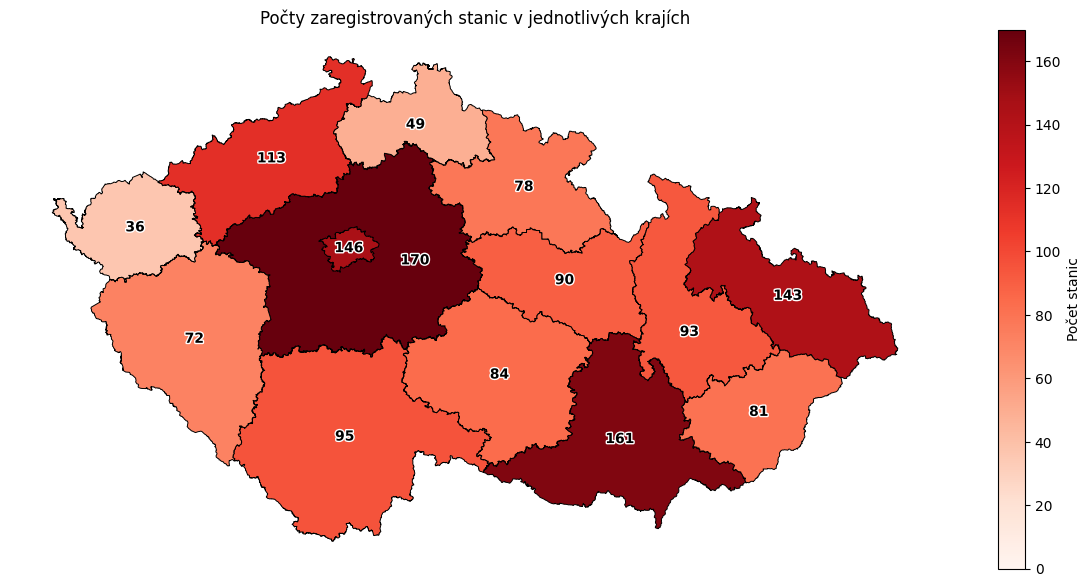

In [81]:
# Definice převodníku
kraje_mapping = {
    "Hlavní město Praha": "CZ0100000000",
    "Středočeský kraj": "CZ0200000000",
    "Jihočeský kraj": "CZ0310000000",
    "Plzeňský kraj": "CZ0320000000",
    "Karlovarský kraj": "CZ0410000000",
    "Ústecký kraj": "CZ0420000000",
    "Liberecký kraj": "CZ0510000000",
    "Královéhradecký kraj": "CZ0520000000",
    "Pardubický kraj": "CZ0530000000",
    "Vysočina": "CZ0630000000",
    "Jihomoravský kraj": "CZ0640000000",
    "Olomoucký kraj": "CZ0710000000",
    "Zlínský kraj": "CZ0720000000",
    "Moravskoslezský kraj": "CZ0800000000"
}

# Agregace v Polars
counts_pl = df.with_columns(
    pl.col("Stanice_Adresa_Kraj").replace(kraje_mapping).alias("kod_kraje")
).group_by("kod_kraje").agg(
    pl.len().alias("pocet")
)

# Načtení GeoJSON
KRAJE_URL = "https://raw.githubusercontent.com/siwekm/czech-geojson/refs/heads/master/kraje.json"
kraje_geo = gpd.read_file(KRAJE_URL)

# Join dat
map_data = kraje_geo.merge(
    counts_pl.to_pandas(),
    left_on="id",
    right_on="kod_kraje",
    how="left"
).fillna(0)

# Seřazením zajistíme, že Praha bude na konci seznamu a vykreslí se navrch
map_data["z_order"] = map_data["id"].apply(lambda x: 1 if x == "CZ0100000000" else 0)
map_data = map_data.sort_values("z_order")

fig, ax = plt.subplots(figsize=(15, 10))
map_data.plot(
    column="pocet", 
    cmap="Reds", 
    edgecolor="black", 
    vmin=0,
    linewidth=0.7,
    ax=ax, 
    legend=True,
    legend_kwds={
        'label': "Počet stanic",
        'orientation': "vertical",
        'shrink': 0.7
    }
)

# Přidání textových popisků do mapy
for idx, row in map_data.iterrows():
    centroid = row.geometry.centroid
    xy_text_offset = (0, 0) # Žádný posun
    
    # Uprava pro specificke kraje
    if row['id'] == "CZ0200000000":
        xy_text_offset = (40, 0)
    if row['id'] == "CZ0710000000":
        xy_text_offset = (0, -20)

    # Definice bílého obrysu pro text
    text_outline = [path_effects.withStroke(linewidth=2, foreground='white')]

    ax.annotate(
        text=str(int(row['pocet'])),
        xy=(centroid.x, centroid.y),
        xytext=xy_text_offset,
        textcoords="offset points",
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black', # Vnitřek textu zůstane černý
        path_effects=text_outline # Přidání bílého obrysu
    )

ax.set_axis_off()
ax.set_title('Počty zaregistrovaných stanic v jednotlivých krajích')
# Finální export do SVG
plt.savefig("kod/explorace/pocty_stanic_mapa.svg", format="svg", bbox_inches='tight')

# Stanice pod stejným provozovatelem

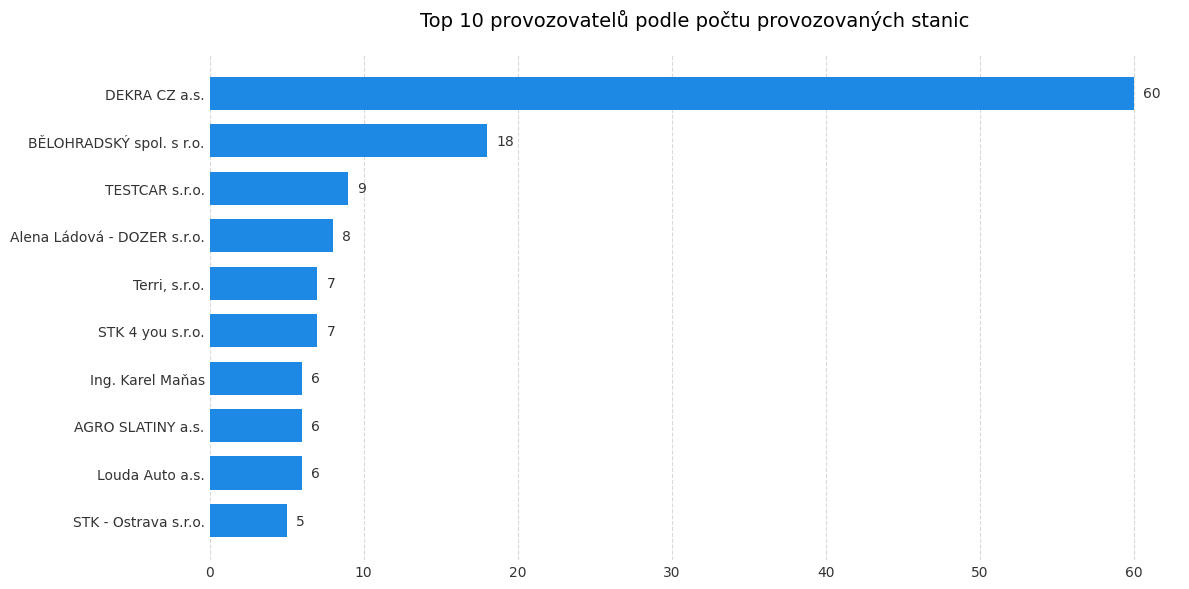

Prumerny pocet stanic jednoho provozovatele 1.4412665985699693


In [106]:
# Definice top n
n = 10

# Příprava dat z Polars DataFrame (df)
top_provozovatele = (
    df.group_by('Provozovatel_Nazev')
    .len()
    .sort(by='len', descending=True)
    .head(n)
    .reverse()
)

labels = top_provozovatele['Provozovatel_Nazev'].to_list()
counts = top_provozovatele['len'].to_list()

# Inicializace grafu se světlým pozadím
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

# Horizontální sloupce
bars = ax.barh(labels, counts, color='#1e88e5', height=0.7)

# Absolutní počty u sloupců
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max(counts) * 0.01), 
        bar.get_y() + bar.get_height()/2, 
        f'{int(width)}', 
        va='center', 
        fontsize=10, 
        color='#333333'
    )

# Formátování a vzhled
ax.set_title(f'Top {n} provozovatelů podle počtu provozovaných stanic', fontsize=14, pad=20, color='black')
ax.tick_params(axis='both', which='both', length=0, labelsize=10, labelcolor='#333333')

# Odstranění linií grafu
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Mřížka pro x-ovou osu
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)

# Export
plt.tight_layout()
plt.savefig("kod/explorace/top_provozovatele.svg", format="svg", bbox_inches='tight', facecolor='white')
plt.show()

print(f'Prumerny pocet stanic jednoho provozovatele {df.group_by('Provozovatel_Nazev').len().select(pl.col('len').mean()).item()}')

In [120]:
print(f'Podíl stanic provozvaných velkými hráči majících STK oprávnění: {df.filter(pl.col('Provozovatel_Nazev').is_in(list(top_provozovatele['Provozovatel_Nazev']))).select((pl.col('Stk_Pritomno') == 'True').mean()).item()*100:.2f} %')

Podíl stanic provozvaných velkými hráči majících STK oprávnění: 55.30 %


# Profile report

In [24]:
profile = ProfileReport(df.to_pandas(), explorative=True)
profile.to_file('kod/reporty/Stanice_STK_a_SME.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:07<00:00,  3.68it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]